### Visualize the Rplan Image

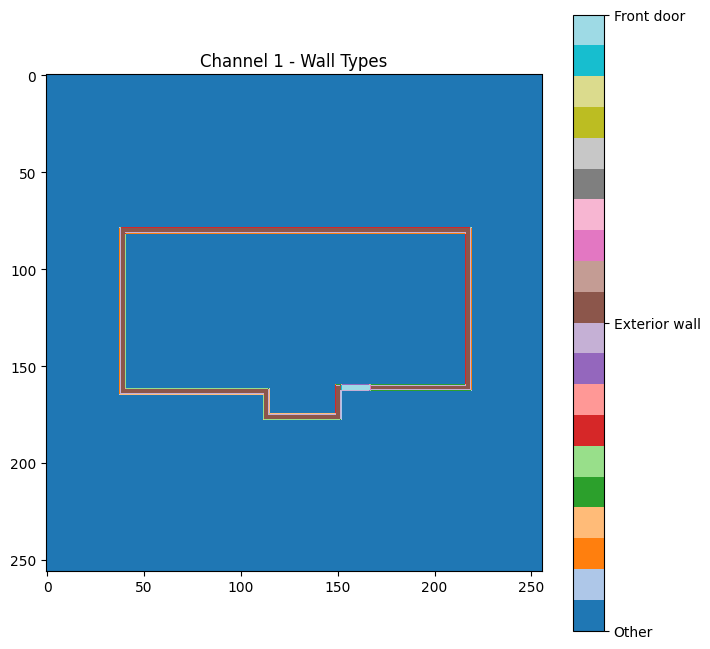

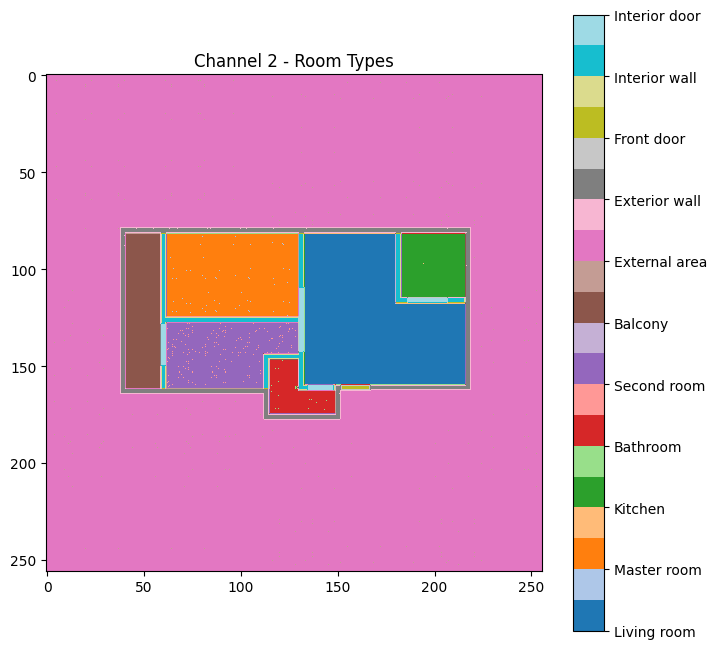

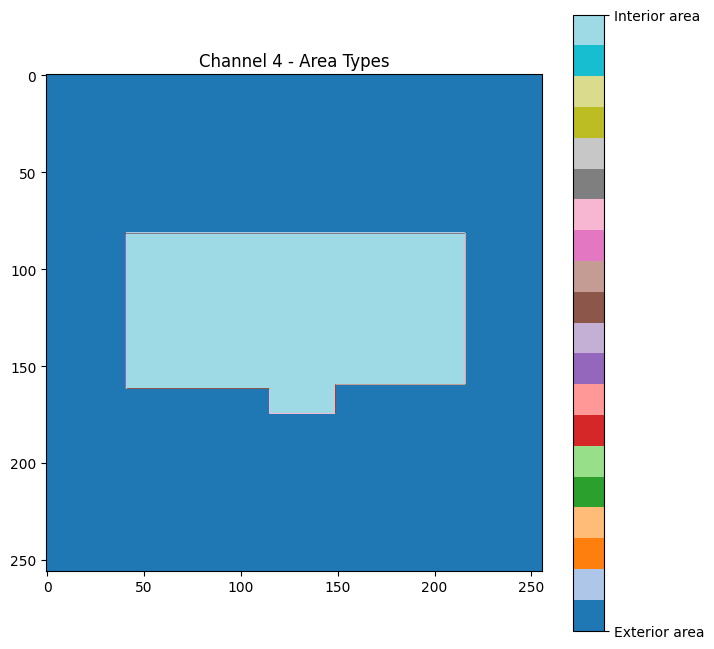

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = "image/291.png"  # Replace with your image path
img = np.array(Image.open(image_path))

# Split channels
channel_1 = img[:, :, 0]
channel_2 = img[:, :, 1]
channel_3 = img[:, :, 2]
channel_4 = img[:, :, 3] if img.shape[2] > 3 else None

# Define mappings based on Excel sheet
channel_1_mapping = {
    127: "Exterior wall",
    255: "Front door",
    0: "Other"
}

room_type = {
    0: "Living room",
    1: "Master room",
    2: "Kitchen",
    3: "Bathroom",
    4: "Dining room",
    5: "Child room",
    6: "Study room",
    7: "Second room",
    8: "Guest room",
    9: "Balcony",
    10: "Entrance",
    11: "Storage",
    12: "Wall-in",
    13: "External area",
    14: "Exterior wall",
    15: "Front door",
    16: "Interior wall",
    17: "Interior door"
}

channel_4_mapping = {
    0: "Exterior area",
    255: "Interior area"
}

# Create a function to visualize the mappings
def visualize_channel(channel, mapping, title):
    unique_values = np.unique(channel)
    color_map = {val: idx for idx, val in enumerate(unique_values)}
    colored_channel = np.vectorize(color_map.get)(channel)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(colored_channel, cmap='tab20')
    cbar = plt.colorbar(ticks=range(len(unique_values)))
    cbar.ax.set_yticklabels([mapping[val] for val in unique_values])
    plt.title(title)
    plt.show()

# Visualize the channels
visualize_channel(channel_1, channel_1_mapping, "Channel 1 - Wall Types")
visualize_channel(channel_2, channel_2_mapping, "Channel 2 - Room Types")
if channel_4 is not None:
    visualize_channel(channel_4, channel_4_mapping, "Channel 4 - Area Types")


### Visualize Random Samples from your JSON Folder

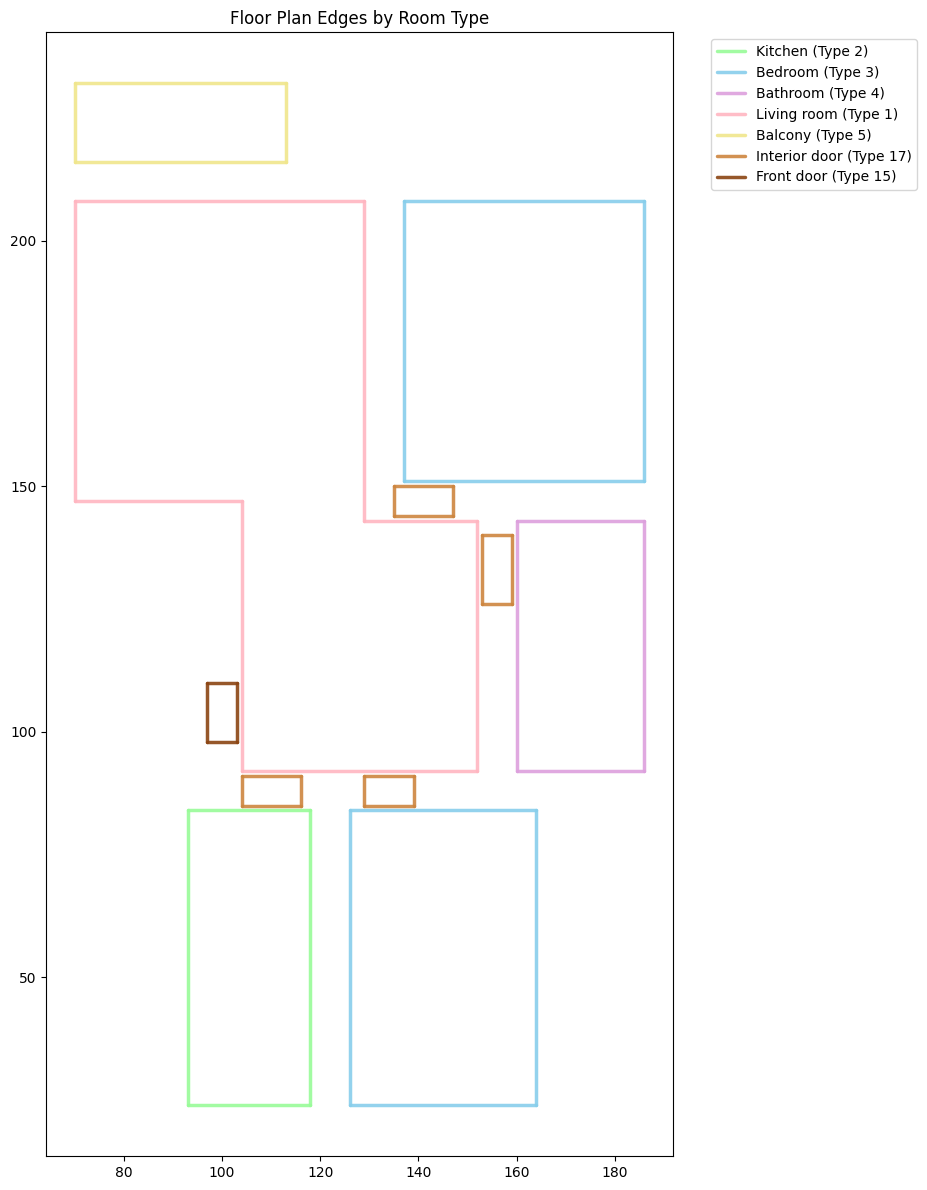

In [ ]:
import json
from visualize import *

def reader(filename):
    with open(filename) as f:
        info = json.load(f)
        rms_bbs = np.array(info['boxes'], dtype=np.float32)
        fp_eds = np.array(info['edges'], dtype=np.float32)[:, :4]
        rms_type = info['room_type']
        eds_to_rms = info['ed_rm']
        return rms_type, fp_eds, rms_bbs, eds_to_rms

# Example usage:
rms_type, fp_eds, rms_bbs, eds_to_rms = reader("rplan_json/8.json")
visualize_floorplan(rms_type, fp_eds, eds_to_rms)